In [11]:
from analyze_experiment import *
from tifffile import imread
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/aman.kukde/sliding_windowed_tiling/microsplit/eval_microsplit/")
import setup_dataloaders
from utils import plot_utils
from microsplit_reproducibility.notebook_utils.custom_dataset_2D import get_input, get_target
from pathlib import Path
import pickle
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches

def load_prediction(path):
    path = Path(path)
    if path.suffix in [".pkl", ".dill"]:
        with open(path, "rb") as f:
            return pickle.load(f)
    else:
        # TIFF expected shape: (N, C, H, W)
        return tiff.imread(path).transpose(0, 2, 3, 1)

In [ ]:
from types import SimpleNamespace
from pathlib import Path

args = SimpleNamespace(
    model_name="microsplit",
    dataset="HT_H24",
    pred_sw="/group/jug/aman/Consolidated_Outputs_11Nov25/Microsplit/HT_H24/pred_test_dset_microsplit_swt.pkl",
    pred_og="/group/jug/aman/Consolidated_Outputs_11Nov25/Microsplit/HT_H24/pred_test_dset_microsplit_og.pkl",
    save_dir="/home/aman.kukde/sliding_windowed_tiling/analysis/local_temp_dir_dataset/HT_H24",
    inner_tile_size=[9,32,32],        # because you passed "9,32,32"
    bins=2000,
    kl_start=29,
    kl_end=33,
    channel="all",
    gradient_based_analysis=True,
    qualitative_analysis=True,
    all=False
)

args.save_dir = Path(args.save_dir)
img_sw = load_prediction(args.pred_sw)
img_og = load_prediction(args.pred_og)

# Determine analyses to run
run_gradient = args.gradient_based_analysis or args.all
run_qualitative = args.qualitative_analysis or args.all

run_gradient_based_analysis_multi(
    inputs={
        "SW": img_sw,
        "OG": img_og,
        "BLUR": img_blur,
        "SHARP": img_sharp
    },
    save_dir=args.save_dir,
    inner_tile_size=args.inner_tile_size,
    bins=args.bins,
    channel=channel,
)

In [ ]:
img_og = load_prediction("/group/jug/aman/Consolidated_Outputs_11Nov25/Microsplit/PAVIA_ATN/pred_test_dset_microsplit_og.pkl")
img_sw = load_prediction("/group/jug/aman/Consolidated_Outputs_11Nov25/Microsplit/PAVIA_ATN/pred_test_dset_microsplit_swt.pkl")
model, experiment_config, train_dset, val_dset, test_dset = setup_dataloaders.setup_dataset_PAVIA_ATN(sliding_window_flag=False)
tar = get_target(test_dset)
inp = get_input(test_dset)
# from microsplit_reproducibility.notebook_utils.HT_LIF24 import get_highsnr_data
# highSNR_test_dset = get_highsnr_data(train_data_config, val_data_config, test_data_config, evaluate_on_validation_data)

In [ ]:
# img_og = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/SC/saved_outputs/HDN_prediction_SC_Convallaria_64_64_32_swt.pkl")
# img_sw = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/SC/saved_outputs/HDN_prediction_SC_Convallaria_64_1_4_swt.pkl")
# img_ot = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/SC/saved_outputs/HDN_prediction_SC_Convallaria_128_64_64_swt.pkl")
# img_full = load_prediction("/home/aman.kukde/sliding_windowed_tiling/HDN/HDN_prediction_SC_64_og.pkl")

root_path = Path("/group/jug/aman/Datasets/Convallaria_diaphragm/data/")
path = root_path/"Convallaria_diaphragm/"
# The test data is just one quater of the full image ([:,:512,:512]) following the works which have used this data earlier
observation= imread(path/'20190520_tl_25um_50msec_05pc_488_130EM_Conv.tif').astype(np.float32)[:,:512,:512]
signal=np.mean(observation[:,...],axis=0)[np.newaxis,...]
img_width, img_height = signal.shape[1], signal.shape[2]
gt = np.tile(signal[0][None, ...], (len(observation), 1, 1))


inp= observation
tar = gt

In [ ]:
# img_og = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Convallaria/saved_outputs/HDN_prediction_Pixed_Convallaria_64_64_32_swt.pkl")
# img_sw = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Convallaria/saved_outputs/HDN_prediction_Pixed_Convallaria_64_1_4_swt.pkl")
# img_ot = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Convallaria/saved_outputs/HDN_prediction_Pixed_Convallaria_128_64_64_swt.pkl")
# img_full = load_prediction("/home/aman.kukde/sliding_windowed_tiling/HDN/HDN_prediction_Convallaria_64_og.pkl")

In [ ]:
# img_og = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Natural/saved_outputs/HDN_prediction_Pixel_Natural_64_64_32_swt.pkl")
# img_sw = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Natural/saved_outputs/HDN_prediction_Pixel_Natural_64_1_4_swt.pkl")
# img_ot = load_prediction("/group/jug/aman/HDN_runs/HDN_14Nov25/Natural/saved_outputs/HDN_prediction_Pixel_Natural_128_64_64_swt.pkl")
# img_full = load_prediction("/home/aman.kukde/sliding_windowed_tiling/HDN/HDN_prediction_Natural_64_og.pkl")

test_images_gt = np.load('/group/jug/aman/Datasets/Natural/data/BSD68_reproducibility_data/test/bsd68_groundtruth.npy', allow_pickle=True)
test_images = np.load('/group/jug/aman/Datasets/Natural/data/BSD68_reproducibility_data/test/bsd68_gaussian25.npy', allow_pickle=True)
inp, idx_inp = fix_flipped_images(test_images)
tar, idx_gt = fix_flipped_images(test_images_gt)


In [24]:
def plot_full_comparison(
    predictions_list,  # list of 2D arrays
    tar_list,          # list of 2D arrays – GT is tar_list[0]
    inp_list,          # list of 2D arrays
    frame_idx,
    titles,            # list of method names
    save_path=None,
    zoom_factor = 4
):


    num_methods = len(predictions_list)
    assert 2 <= num_methods <= 4, "Only 2–4 prediction methods supported."
    assert len(titles) == num_methods, "titles must match number of methods."

    # --- Input & crop ---
    full_input = inp_list[0]
    H, W = full_input.shape
    crop_h, crop_w = H // zoom_factor, W // zoom_factor
    crop_y, crop_x = (H - crop_h) // 2, (W - crop_w) // 2
    crop_slice_y = slice(crop_y, crop_y + crop_h)
    crop_slice_x = slice(crop_x, crop_x + crop_w)

    input_zoom = full_input[crop_slice_y, crop_slice_x]
    gt = tar_list[0]
    gt_zoom = gt[crop_slice_y, crop_slice_x]
    preds_zoom = [p[crop_slice_y, crop_slice_x] for p in predictions_list]

    # Text label for zoom region
    zoom_label = f"Zoom: y[{crop_y}:{crop_y+crop_h}], x[{crop_x}:{crop_x+crop_w}]"

    # --- Figure setup ---
    fig = plt.figure(figsize=(4*(4 if num_methods<=2 else num_methods+2), 12))
    gs = GridSpec(3, max(4, num_methods), figure=fig, wspace=0.1, hspace=0.15)

    # -----------------------
    # Row 0: Input (Full)
    # -----------------------
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(full_input, vmin=full_input.min(), vmax=full_input.max())
    # Yellow crop box
    rect = patches.Rectangle((crop_x, crop_y), crop_w, crop_h,
                             linewidth=2, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect)

    # Add the zoom-region coordinates (top-left corner of box)
    ax.text(crop_x, crop_y-5, zoom_label,
            color='yellow', fontsize=10, backgroundcolor='black')

    ax.set_title("Input (Full)")
    ax.axis("off")

    # -----------------------
    # Input Zoom
    # -----------------------
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(input_zoom, vmin=input_zoom.min(), vmax=input_zoom.max())
    ax.set_title("Input (Zoom)")
    ax.axis("off")

    # -----------------------
    # GT Full
    # -----------------------
    ax = fig.add_subplot(gs[0, 2])
    ax.imshow(gt, vmin=gt.min(), vmax=gt.max())
    ax.add_patch(patches.Rectangle((crop_x, crop_y), crop_w, crop_h,
                                   linewidth=2, edgecolor='yellow', facecolor='none'))
    ax.text(crop_x, crop_y-5, zoom_label,
            color='yellow', fontsize=10, backgroundcolor='black')
    ax.set_title("GT (Full)")
    ax.axis("off")

    # -----------------------
    # GT Zoom
    # -----------------------
    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(gt_zoom, vmin=gt_zoom.min(), vmax=gt_zoom.max())
    ax.set_title("GT (Zoom)")
    ax.axis("off")

    # -----------------------
    # Row 1: Predictions zoomed
    # -----------------------
    for i in range(num_methods):
        ax = fig.add_subplot(gs[1, i])
        ax.imshow(preds_zoom[i], vmin=preds_zoom[i].min(), vmax=preds_zoom[i].max())
        ax.set_title(f"{titles[i]} (Zoom)")
        ax.axis("off")

    # -----------------------
    # Row 2: Predictions full
    # -----------------------
    for i in range(num_methods):
        ax = fig.add_subplot(gs[2, i])
        ax.imshow(predictions_list[i]),# vmin=predictions_list[i].min(), vmax=predictions_list[i].max())
        ax.set_title(f"{titles[i]} (Full)")
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close(fig)
    else:
        plt.show()


In [25]:
idx = 5
plot_full_comparison(
    predictions_list=[img_og[idx], img_sw[idx], img_ot[idx], img_full[idx]],
    tar_list=[tar[idx], tar[idx], tar[idx], tar[idx]],
    inp_list=[inp[idx], inp[idx], inp[idx], inp[idx]],
    frame_idx=idx,
    titles=["Inner Tiling", "Sliding Inner Tiling", "Outer - Tiling", "Full Image"],
    zoom_factor = 4,
)

NameError: name 'img_og' is not defined

In [ ]:
idx = 5
plot_full_comparison(
    predictions_list=[img_og[idx], img_sw[idx], img_ot[idx], img_full[idx]],
    tar_list=[tar[idx], tar[idx], tar[idx], tar[idx]],
    inp_list=[inp[idx], inp[idx], inp[idx], inp[idx]],
    frame_idx=idx,
    titles=["Inner Tiling", "Sliding Inner Tiling", "Outer - Tiling", "Full Image"],
    zoom_factor = 4
)

In [8]:

def full_frame_evaluation_zoomed(
    predictions_list,
    tar_list,
    inp_list,
    frame_idx,
    titles,
    save_path=None
):
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as patches
    import numpy as np

    # Validate input lengths
    n_methods = len(predictions_list)
    assert len(tar_list) == n_methods and len(inp_list) == n_methods, \
        "predictions_list, tar_list, and inp_list must have the same length"
    assert len(titles) >= n_methods, \
        "titles must have at least as many entries as there are methods"

    # === Normalization range based on GT ===
    all_targets = np.concatenate([t for t in tar_list], axis=-1)
    vmin = np.nanpercentile(all_targets, 1)
    vmax = np.nanpercentile(all_targets, 99)
    if vmin == vmax:
        vmin, vmax = 0, 1

    # === Figure setup ===
    fig = plt.figure(figsize=(22, 16), constrained_layout=True)
    gs = GridSpec(3, 4, figure=fig)
    plt.rcParams.update({'font.size': 12})

    # === Compute full input and crop region ===
    full_input_img = np.mean(inp_list[0][..., :2], axis=-1)
    H, W = full_input_img.shape
    crop_h = H // 4
    crop_w = W // 4
    crop_y = (H - crop_h) // 2
    crop_x = (W - crop_w) // 2
    crop_slice_y = slice(crop_y, crop_y + crop_h)
    crop_slice_x = slice(crop_x, crop_x + crop_w)
    rect_kwargs = dict(linewidth=2, edgecolor='yellow', facecolor='none')

    # === Prepare crops ===
    preds_crops = []
    targets_crops = []
    for i in range(n_methods):
        targets_crops.append(tar_list[i][crop_slice_y, crop_slice_x, :])
        preds_crops.append(predictions_list[i][crop_slice_y, crop_slice_x, :])

    # === Row 1: GTs, full input, zoomed input ===
    full_target = tar_list[0]

    # GT channel 0
    ax_gt0 = fig.add_subplot(gs[0, 0])
    ax_gt0.imshow(full_target[..., 0], cmap='gray', vmin=vmin, vmax=vmax)
    ax_gt0.set_title("GT Channel 0 (Full)")
    ax_gt0.add_patch(patches.Rectangle((crop_x, crop_y), crop_w, crop_h, **rect_kwargs))
    ax_gt0.axis('off')

    # GT channel 1
    ax_gt1 = fig.add_subplot(gs[0, 1])
    ax_gt1.imshow(full_target[..., 1], cmap='gray', vmin=vmin, vmax=vmax)
    ax_gt1.set_title("GT Channel 1 (Full)")
    ax_gt1.add_patch(patches.Rectangle((crop_x, crop_y), crop_w, crop_h, **rect_kwargs))
    ax_gt1.axis('off')

    # Full input
    ax_inp_full = fig.add_subplot(gs[0, 2])
    ax_inp_full.imshow(full_input_img, cmap='gray', vmin=vmin, vmax=vmax)
    ax_inp_full.set_title(f"{titles[0]} Input (Frame {frame_idx})")
    ax_inp_full.add_patch(patches.Rectangle((crop_x, crop_y), crop_w, crop_h, **rect_kwargs))
    ax_inp_full.axis('off')

    # Zoomed input
    ax_inp_zoom = fig.add_subplot(gs[0, 3])
    ax_inp_zoom.imshow(full_input_img[crop_slice_y, crop_slice_x], cmap='gray', vmin=vmin, vmax=vmax)
    ax_inp_zoom.set_title("Zoomed Input")
    ax_inp_zoom.axis('off')

    # === Row 2: Predictions (Channel 0) ===
    ax_pred_orig_ch0 = fig.add_subplot(gs[1, 0])
    ax_pred_orig_ch0.imshow(preds_crops[0][..., 0], cmap='gray', vmin=vmin, vmax=vmax)
    ax_pred_orig_ch0.set_title(f"{titles[0]} Prediction Ch0")
    ax_pred_orig_ch0.axis('off')

    ax_pred_slide_ch0 = fig.add_subplot(gs[1, 1])
    ax_pred_slide_ch0.imshow(preds_crops[1][..., 0], cmap='gray', vmin=vmin, vmax=vmax)
    ax_pred_slide_ch0.set_title(f"{titles[1]} Prediction Ch0")
    ax_pred_slide_ch0.axis('off')

    # Add GT ch0 again for visual alignment reference
    ax_gt_crop_ch0 = fig.add_subplot(gs[1, 2])
    ax_gt_crop_ch0.imshow(targets_crops[0][..., 0], cmap='gray', vmin=vmin, vmax=vmax)
    ax_gt_crop_ch0.set_title("GT Ch0 (Crop)")
    ax_gt_crop_ch0.axis('off')

    # Optional: difference map between two methods (abs diff)
    diff_ch0 = np.abs(preds_crops[0][..., 0] - preds_crops[1][..., 0])
    ax_diff_ch0 = fig.add_subplot(gs[1, 3])
    ax_diff_ch0.imshow(diff_ch0, cmap='magma')
    ax_diff_ch0.set_title("|Diff| Ch0")
    ax_diff_ch0.axis('off')

    # === Row 3: Predictions (Channel 1) ===
    ax_pred_orig_ch1 = fig.add_subplot(gs[2, 0])
    ax_pred_orig_ch1.imshow(preds_crops[0][..., 1], cmap='gray', vmin=vmin, vmax=vmax)
    ax_pred_orig_ch1.set_title(f"{titles[0]} Prediction Ch1")
    ax_pred_orig_ch1.axis('off')

    ax_pred_slide_ch1 = fig.add_subplot(gs[2, 1])
    ax_pred_slide_ch1.imshow(preds_crops[1][..., 1], cmap='gray', vmin=vmin, vmax=vmax)
    ax_pred_slide_ch1.set_title(f"{titles[1]} Prediction Ch1")
    ax_pred_slide_ch1.axis('off')

    # Add GT ch1 again for comparison
    ax_gt_crop_ch1 = fig.add_subplot(gs[2, 2])
    ax_gt_crop_ch1.imshow(targets_crops[0][..., 1], cmap='gray', vmin=vmin, vmax=vmax)
    ax_gt_crop_ch1.set_title("GT Ch1 (Crop)")
    ax_gt_crop_ch1.axis('off')

    # Optional: difference map for ch1
    diff_ch1 = np.abs(preds_crops[0][..., 1] - preds_crops[1][..., 1])
    ax_diff_ch1 = fig.add_subplot(gs[2, 3])
    ax_diff_ch1.imshow(diff_ch1, cmap='magma')
    ax_diff_ch1.set_title("|Diff| Ch1")
    ax_diff_ch1.axis('off')

    # === Margins and spacing ===
    fig.subplots_adjust(
        left=0.10,
        right=0.90,
        top=0.90,
        bottom=0.10,
        wspace=0.10,
        hspace=0.50
    )

    # === Save or show ===
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close(fig)
    else:
        plt.show()

idx = 0
full_frame_evaluation_zoomed(
    predictions_list=[img_og[idx], img_sw[idx]],
    tar_list=[test_dset._data[idx], test_dset._data[idx]],
    inp_list=[inp[idx], inp[idx]],
    frame_idx=idx,
    titles=["Inner Tiling", "Sliding Inner Tiling"],
)

NameError: name 'img_og' is not defined

In [9]:
def fix_flipped_images(images):
    """
    Detects and fixes flipped (transposed) images in a list or np.ndarray.
    Assumes most images have the correct orientation.

    Parameters
    ----------
    images : list or np.ndarray
        List of images, each a numpy array (H, W) or (C, H, W).

    Returns
    -------
    fixed_images : list of np.ndarray
        Images with flipped ones corrected.
    flipped_indices : list of int
        Indices of images that were flipped.
    """

    # Convert to list if ndarray
    if isinstance(images, np.ndarray):
        images = list(images)

    # Get the most common shape as reference
    shapes = [img.shape[-2:] for img in images]  # last two dims (H, W)
    unique, counts = np.unique(shapes, axis=0, return_counts=True)
    reference_shape = unique[np.argmax(counts)]  # most frequent (H, W)

    fixed_images = []
    flipped_indices = []

    for idx, img in enumerate(images):
        h, w = img.shape[-2:]
        ref_h, ref_w = reference_shape

        # If flipped shape detected
        if (h, w) == (ref_w, ref_h):
            # Flip the last two dimensions
            if img.ndim == 2:
                img_fixed = img.T
            else:
                img_fixed = np.transpose(img, (0, 2, 1))  # (C, H, W)
            fixed_images.append(img_fixed)
            flipped_indices.append(idx)
        else:
            fixed_images.append(img)

    return np.array(fixed_images), flipped_indices


In [32]:
import os
import subprocess
from multiprocessing import Pool, cpu_count
from pathlib import Path

ROOT_DIR = Path("/group/jug/aman/HDN_runs/HDN_28Nov25/saved_outputs_sw/")
OUTPUT_BASE = Path("HDN/Analysis_indivitual_runs/")
NOISE_LEVELS = [20, 40, 60, 80, 100]
MODALITIES = ["IT", "OT", "SIT"]
MODEL_NAME = "HDN"
METHOD_NAMES = "IT, OT, SIT"

# Auto-detect datasets inside ROOT_DIR
DATASETS = [d.name for d in ROOT_DIR.iterdir() if d.is_dir()]

def run_single_job(args):
    dataset, noise = args

    print(f"Starting job: Dataset={dataset}, Noise={noise}")

    pred_files = []
    for mod in MODALITIES:
        folder = ROOT_DIR / dataset / f"Noise_{noise}" / mod 
        files = list(folder.glob("*.pkl")) + list(folder.glob("*.tiff"))

        if not files:
            print(f"❌ Missing prediction file in {folder}")
            return

        pred_files.append(str(files[0]))

    pred_csv = ",".join(pred_files)
    save_dir = OUTPUT_BASE / dataset / f"Noise_{noise}"
    save_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python3", "analyze_experiment.py",
        "--model_name", MODEL_NAME,
        "--dataset", dataset,
        "--predictions", pred_csv,
        "--method_names", METHOD_NAMES,
        "--save_dir", str(save_dir),
        # "--gradient_analysis",
        "--inner_tile_size", "32,64,32",
    ]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd)

    print(f"✔ Finished job: Dataset={dataset}, Noise={noise}")


if __name__ == "__main__":
    # Create full job list
    job_list = [(dataset, noise) for dataset in DATASETS for noise in NOISE_LEVELS]

    print("======================================")
    print(" Running HDN Analysis Locally in Parallel")
    print(f" Detected datasets: {DATASETS}")
    print(" Jobs:", job_list)
    print("======================================\n")

    # Use all CPU cores
    workers = min(len(job_list), cpu_count())
    print(f"Using {workers} parallel workers.\n")

    with Pool(workers) as pool:
        pool.map(run_single_job, job_list)

    print("\n🔥 ALL JOBS COMPLETE")


 Running HDN Analysis Locally in Parallel
 Detected datasets: ['SC', 'Convallaria']
 Jobs: [('SC', 20), ('SC', 40), ('SC', 60), ('SC', 80), ('SC', 100), ('Convallaria', 20), ('Convallaria', 40), ('Convallaria', 60), ('Convallaria', 80), ('Convallaria', 100)]

Using 4 parallel workers.

Starting job: Dataset=SC, Noise=80Starting job: Dataset=SC, Noise=20Starting job: Dataset=SC, Noise=60Starting job: Dataset=SC, Noise=40



Running:Running: python3 analyze_experiment.py --model_name HDN --dataset SC --predictions /group/jug/aman/HDN_runs/HDN_28Nov25/saved_outputs_sw/SC/Noise_60/IT/HDN_prediction_SC_Convallaria_64_64_32_swt.pkl,/group/jug/aman/HDN_runs/HDN_28Nov25/saved_outputs_sw/SC/Noise_60/OT/HDN_prediction_SC_Convallaria_128_64_64_swt.pkl,/group/jug/aman/HDN_runs/HDN_28Nov25/saved_outputs_sw/SC/Noise_60/SIT/HDN_prediction_SC_Convallaria_64_1_4_swt.pkl --method_names IT, OT, SIT --save_dir HDN/Analysis_indivitual_runs/SC/Noise_60 --inner_tile_size 32,64,32Running:Running:  python3 ana

In [33]:
from pathlib import Path
import numpy as np
import pickle
from PIL import Image
from skimage.io import imread

def load_image_any(path):
    path = Path(path)
    if path.suffix == ".pkl":
        with open(path, "rb") as f:
            return pickle.load(f)
    else:
        return np.array(Image.open(path))

def plot_modalities(dataset, noise, root_dir, zoom_factor=4):
    """
    Loads IT, OT, SIT predictions + input + GT and calls plot_full_comparison().
    """
    root_dir = Path(root_dir)
    mods = ["IT", "OT", "SIT"]

    # ------------------------------------------------------
    # Load input and ground truth (dataset-dependent)
    # ------------------------------------------------------
    if dataset == "Natural":
        test_images_gt = np.load(
            "/group/jug/aman/Datasets/Natural/data/BSD68_reproducibility_data/test/bsd68_groundtruth.npy",
            allow_pickle=True
        )
        test_images = np.load(
            "/group/jug/aman/Datasets/Natural/data/BSD68_reproducibility_data/test/bsd68_gaussian25.npy",
            allow_pickle=True
        )

        inp, _ = fix_flipped_images(test_images)
        tar, _ = fix_flipped_images(test_images_gt)

        # Use frame 0
        inp_list = [inp[0]]
        tar_list = [tar[0]]

    elif dataset in ["Convallaria", "SC"]:
        root_path = Path("/group/jug/aman/Datasets/Convallaria_diaphragm/data/")
        path = root_path / "Convallaria_diaphragm/"

        observation = imread(path / "20190520_tl_25um_50msec_05pc_488_130EM_Conv.tif") \
                        .astype(np.float32)[:, :512, :512]

        signal = np.mean(observation, axis=0)[None, ...]
        gt = np.tile(signal[0][None, ...], (len(observation), 1, 1))

        inp_list = [observation[0]]
        tar_list = [gt[0]]

    else:
        raise ValueError(f"Unknown dataset: {dataset}")

    # ------------------------------------------------------
    # Load IT, OT, SIT predictions
    # ------------------------------------------------------
    predictions_list = []

    for mod in mods:
        folder = root_dir / dataset / f"Noise_{noise}" / mod
        files = list(folder.glob("*.pkl")) + list(folder.glob("*.tiff"))

        if not files:
            raise FileNotFoundError(f"No prediction found in {folder}")

        pred = load_image_any(files[0])

        # assume [C,H,W] → take channel 0
        if pred.ndim == 3:
            pred = pred[0]
        predictions_list.append(pred)

    # ------------------------------------------------------
    # Call your master plotting function
    # ------------------------------------------------------
    plot_full_comparison(
        predictions_list=predictions_list,
        tar_list=tar_list,
        inp_list=inp_list,
        frame_idx=1,
        titles=mods,
        save_path=None,
        zoom_factor=zoom_factor
    )


/tmp/ipykernel_14104/2892442407.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


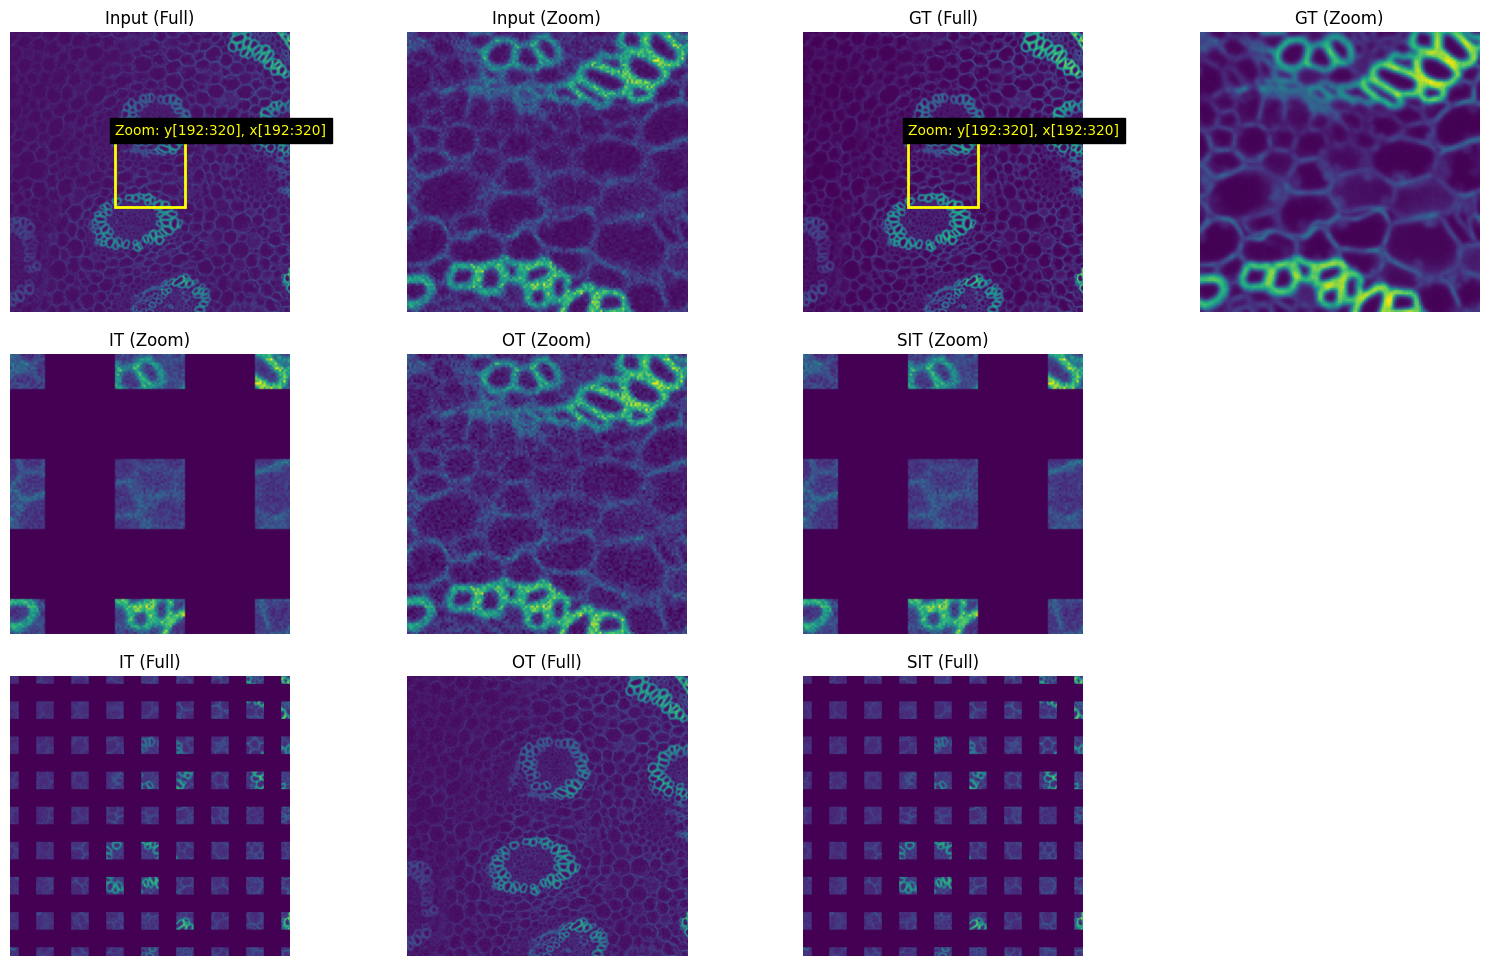

In [34]:
ROOT_DIR = "/group/jug/aman/HDN_runs/HDN_28Nov25/saved_outputs_sw/"
plot_modalities("Convallaria", noise=100, root_dir=ROOT_DIR)
